# TCM-IDS: Temporal Contrastive Mamba for Multi-Attack Intrusion Detection

This notebook contains the complete implementation and evaluation of **TCM-IDS**, a three‑stage intrusion detection framework that combines:

- **Selective State Space Modelling (Mamba SSM)** linear‑time temporal encoding of network flow sequences.
- **Convolutional Block Attention Module (CBAM)**  channel and spatial attention to highlight discriminative features.
- **Supervised Contrastive Learning (SupCon) with Hard Negative Mining** – explicitly maximises inter‑class embedding margins, targeting the most confusing attack boundaries.

## Purpose

The notebook demonstrates that a single fixed architecture, without dataset‑specific tuning, achieves strong multi‑class detection performance on two heterogeneous datasets:

- **RT‑IoT2022**  real IoT testbed traffic (MQTT, ARP spoofing, Nmap reconnaissance, DoS).
- **CIC‑IDS2017**  enterprise network traffic (7 attack categories including DDoS, botnet, port scan, and brute‑force).

## Key Results

| Dataset | Macro‑F1 | Accuracy | AUC‑OVR | Avg Latency (CPU, TorchScript) |
|---------|----------|----------|---------|--------------------------------|
| RT‑IoT2022   | 0.9513 ± 0.0005 | 0.9836 | 0.9972 | 3.923 ms |
| CIC‑IDS2017  | 0.8945 ± 0.0010 | 0.9602 | 0.9958 | 3.588 ms |

- Both models satisfy the Liu–Layland real‑time schedulability bound at a 10 ms IIoT period ($U<0.828$).
- Multi‑seed evaluation (5 seeds) with 95 % confidence intervals and Shapiro‑Wilk normality tests ensures statistical robustness.

## Notebook Structure

1. **Cell 1**  Imports, global configuration, and hyperparameters.
2. **Cell 2**  Architecture definitions: SelectiveSSM, CBAM, TCMEncoder, TCMClassifier, SupCon with hard negative mining, SlidingWindowDataset.
3. **Cell 3**  Training & evaluation functions (three‑stage protocol).
4. **Cell 4**  Loading and evaluation of pre‑trained RT‑IoT2022 model.
5. **Cell 5**  Full training of CIC‑IDS2017 from scratch (three stages).
6. **Cell 5b**  Loading and evaluation of pre‑trained CIC‑IDS2017 model (optional).
7. **Cell 6**  Multi‑seed statistical evaluation (5 seeds).
8. **Cell 7**  Figures: confusion matrices, per‑class F1, summary metrics.
9. **Cell 8**  Latency benchmark with TorchScript compilation and schedulability analysis.

The entire pipeline is self‑contained and runs on CPU‑only hardware, making it suitable for edge deployment in IIoT and OT environments. All results are reproducible and all numbers reported in the paper are directly generated from this notebook.

In [13]:
# CELL 1: Imports & Global Configuration
print('CELL 1: Setup\n')

import os, gc, random, time, warnings, json, platform
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score, matthews_corrcoef
)
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 0

# Architecture
PROJ_DIM   = 64
D_MODEL    = 128
D_STATE    = 16
D_CONV     = 4
EXPAND     = 2
N_LAYERS   = 3
DROPOUT    = 0.25
EMB_DIM    = 128
SEQ_LEN    = 16

# Training
BATCH_TRAIN     = 512
BATCH_INFER     = 1024
LR_PRETRAIN     = 5e-4
LR_PROBE        = 1e-3
LR_FINETUNE     = 1e-4
EPOCHS_PRETRAIN = 20
EPOCHS_PROBE    = 10
EPOCHS_FINETUNE = 15
PATIENCE        = 5
TEMPERATURE     = 0.07
LAMBDA_CON      = 0.3
CIC_CAP         = 150_000

BASE = Path(r'F:\jupyter\kagglehub')
OUT  = Path(r'F:\jupyter\kagglehub\outputs_tcmids_v2')
OUT.mkdir(parents=True, exist_ok=True)
OUT_OLD = Path(r'F:\jupyter\kagglehub\outputs_tcmids')  # where RT-IoT2022 models are saved

matplotlib.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.labelweight': 'bold', 'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'DejaVu Sans'
})

DS_COLOURS = {'rt_iot': '#e6194b', 'cicids2017': '#3cb44b'}
DS_LABELS  = {'rt_iot': 'RT-IoT2022', 'cicids2017': 'CIC-IDS2017'}

results       = {}
models        = {}
all_histories = {}

print(f'Device : {device}')
print(f'Output : {OUT}')
print('CELL 1 COMPLETE')


CELL 1: Setup

Device : cpu
Output : F:\jupyter\kagglehub\outputs_tcmids_v2
CELL 1 COMPLETE


In [14]:
# CELL 2: TCM-IDS Architecture (Selective SSM + CBAM + SupCon)
print('CELL 2: Architecture\n')

class SelectiveSSM(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_inner = int(expand * d_model)
        self.d_state = d_state
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(self.d_inner, self.d_inner,
                                 kernel_size=d_conv, groups=self.d_inner,
                                 padding=d_conv-1, bias=True)
        self.x_proj  = nn.Linear(self.d_inner, d_state*2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)
        A = torch.arange(1, d_state+1, dtype=torch.float).unsqueeze(0).expand(self.d_inner, -1)
        self.A_log   = nn.Parameter(torch.log(A))
        self.D       = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj= nn.Linear(self.d_inner, d_model, bias=False)
        self.norm    = nn.LayerNorm(d_model)
        with torch.no_grad():
            self.dt_proj.bias.uniform_(-4.0, -1.0)

    def selective_scan(self, u, delta, A, B, C, D):
        B_sz, L, d = u.shape
        delta = torch.clamp(delta, min=1e-4, max=1.0)
        dA = torch.exp(torch.clamp(
            delta.unsqueeze(-1) * (-A.unsqueeze(0).unsqueeze(0)),
            min=-20.0, max=0.0))
        dB = delta.unsqueeze(-1) * B.unsqueeze(2)
        h  = torch.zeros(B_sz, d, self.d_state, device=u.device, dtype=u.dtype)
        ys = []
        for i in range(L):
            h = dA[:, i] * h + dB[:, i] * u[:, i].unsqueeze(-1)
            h = torch.clamp(h, min=-1e4, max=1e4)
            ys.append((h * C[:, i].unsqueeze(1)).sum(-1))
        return torch.stack(ys, 1) + u * D.unsqueeze(0).unsqueeze(0)

    def forward(self, x):
        res = x; x = self.norm(x)
        xz  = self.in_proj(x)
        x_, z = xz.chunk(2, -1)
        x_ = self.conv1d(x_.transpose(1,2))[...,:x.shape[1]].transpose(1,2)
        x_ = F.silu(x_)
        p   = self.x_proj(x_)
        B_p = p[..., :self.d_state]
        C_p = p[..., self.d_state:2*self.d_state]
        delta = F.softplus(self.dt_proj(p[..., -1:]))
        A   = -torch.exp(torch.clamp(self.A_log.float(), max=5.0))
        y   = self.selective_scan(x_, delta, A, B_p, C_p, self.D)
        y   = torch.nan_to_num(y, nan=0.0, posinf=1e4, neginf=-1e4)
        return self.out_proj(y * F.silu(z)) + res


class CBAM(nn.Module):
    def __init__(self, ch, r=8, k=7):
        super().__init__()
        self.ca = nn.Sequential(
            nn.Linear(ch, max(1, ch//r)), nn.ReLU(),
            nn.Linear(max(1, ch//r), ch))
        self.sa = nn.Conv1d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        w  = torch.sigmoid(self.ca(x.mean(-1)) + self.ca(x.amax(-1)))
        x  = x * w.unsqueeze(-1)
        sa = torch.sigmoid(self.sa(torch.cat([x.mean(1,True), x.amax(1,True)], 1)))
        return x * sa


class TCMEncoder(nn.Module):
    def __init__(self, input_dim, proj_dim=64, d_model=128,
                 d_state=16, d_conv=4, expand=2, n_layers=3,
                 dropout=0.25, emb_dim=128):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, proj_dim),
            nn.LayerNorm(proj_dim), nn.GELU())
        self.embed     = nn.Linear(proj_dim, d_model)
        self.mambas    = nn.ModuleList([
            SelectiveSSM(d_model, d_state, d_conv, expand) for _ in range(n_layers)])
        self.cbam      = CBAM(d_model)
        self.drop      = nn.Dropout(dropout)
        self.proj_head = nn.Sequential(
            nn.Linear(d_model + proj_dim, 256), nn.ReLU(),
            nn.Linear(256, emb_dim))

    def encode(self, x):
        z    = self.proj(x)
        skip = z[:, -1, :]
        h    = self.embed(z)
        for m in self.mambas:
            h = m(h)
        h = self.cbam(h.transpose(1,2)).transpose(1,2)
        h = self.drop(h.mean(1))
        return torch.cat([h, skip], -1)

    def forward(self, x):
        rep = self.encode(x)
        emb = self.proj_head(rep)
        emb = torch.nan_to_num(emb, nan=0.0, posinf=1e4, neginf=-1e4)
        return F.normalize(emb, dim=-1, eps=1e-8)


class TCMClassifier(nn.Module):
    def __init__(self, encoder, n_classes, d_model=128, proj_dim=64, dropout=0.25):
        super().__init__()
        self.encoder = encoder
        combined     = d_model + proj_dim
        self.head    = nn.Sequential(
            nn.Linear(combined, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),     nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes))
    def forward(self, x):
        return self.head(self.encoder.encode(x))
    def freeze_encoder(self):
        for p in self.encoder.parameters(): p.requires_grad_(False)
    def unfreeze_encoder(self):
        for p in self.encoder.parameters(): p.requires_grad_(True)


class SupConHardNeg(nn.Module):
    def __init__(self, temperature=0.07, hard_neg_k=None):
        super().__init__()
        self.temp = temperature
        self.k    = hard_neg_k
    def forward(self, features, labels):
        B   = features.shape[0]
        sim = torch.clamp(torch.matmul(features, features.T) / self.temp,
                          min=-30.0, max=30.0)
        labels    = labels.contiguous().view(-1, 1)
        pos_mask  = (labels == labels.T).float()
        self_mask = torch.eye(B, device=features.device)
        pos_mask  = pos_mask - self_mask
        neg_mask  = (1 - (labels == labels.T).float() - self_mask).clamp(min=0)
        if self.k is not None and self.k > 0 and neg_mask.sum() > 0:
            with torch.no_grad():
                neg_sims = sim * neg_mask + (-1e9) * (1 - neg_mask)
                k_eff    = min(self.k, int(neg_mask.sum(1).max().item()))
                if k_eff > 0:
                    thresh   = neg_sims.topk(k_eff, dim=1).values[:, -1:]
                    hard_neg = (neg_sims >= thresh).float() * neg_mask
                else:
                    hard_neg = neg_mask
            denom_mask = pos_mask + hard_neg
        else:
            denom_mask = pos_mask + neg_mask
        exp_sim   = torch.exp(sim) * (1 - self_mask)
        log_denom = torch.log(exp_sim.sum(1, keepdim=True) + 1e-8)
        n_pos     = pos_mask.sum(1).clamp(min=1)
        loss      = -((sim - log_denom) * pos_mask).sum(1) / n_pos
        valid     = pos_mask.sum(1) > 0
        if not valid.any():
            return torch.tensor(0., device=features.device, requires_grad=True)
        return loss[valid].mean()


class SlidingWindowDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.y = torch.from_numpy(y.astype(np.int64))
        self.L = seq_len
        self.n = max(0, len(X) - seq_len + 1)
    def __len__(self): return self.n
    def __getitem__(self, i):
        return self.X[i:i+self.L], self.y[i+self.L-1]


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Stability check
_enc = TCMEncoder(50, PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND, N_LAYERS, DROPOUT, EMB_DIM)
_x   = torch.randn(8, SEQ_LEN, 50) * 50
_out = _enc(_x)
assert not torch.isnan(_out).any() and not torch.isinf(_out).any(), 'Stability check FAILED'
print(f'Encoder params : {count_params(_enc):,}')
print('Stability check passed.')
del _enc, _x, _out
print('CELL 2 COMPLETE')


CELL 2: Architecture

Encoder params : 437,726
Stability check passed.
CELL 2 COMPLETE


In [15]:
# CELL 3: Training & Evaluation Functions
print('CELL 3: Training Functions\n')

@torch.no_grad()
def evaluate(model, loader, device, n_cls):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for xb, yb in loader:
        xb     = torch.nan_to_num(xb.to(device), nan=0., posinf=0., neginf=0.)
        logits = model(xb)
        probs  = F.softmax(logits, -1).cpu().numpy()
        preds  = logits.argmax(-1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    mf1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc    = accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except:
        auc = 0.0
    return mf1, acc, auc, y_true, y_pred, y_prob


def train_stage1_supcon(encoder, tr_ldr, val_ldr, epochs, lr,
                         patience, device, n_cls, tag=''):
    supcon    = SupConHardNeg(temperature=TEMPERATURE, hard_neg_k=n_cls*2).to(device)
    probe     = nn.Linear(EMB_DIM, n_cls).to(device)
    optimizer = optim.AdamW(
        list(encoder.parameters()) + list(probe.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_f1, best_state, pat_ctr = 0., None, 0
    history = []
    for ep in range(1, epochs+1):
        encoder.train(); probe.train()
        ep_loss = 0.
        for xb, yb in tr_ldr:
            xb = torch.nan_to_num(xb.to(device), nan=0., posinf=0., neginf=0.)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            emb     = encoder(xb)
            sc_loss = supcon(emb, yb)
            ce_loss = F.cross_entropy(probe(emb.detach()), yb)
            loss    = sc_loss + 0.1 * ce_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
            optimizer.step()
            ep_loss += sc_loss.item()
        scheduler.step()
        encoder.eval(); probe.eval()
        vp, vl = [], []
        with torch.no_grad():
            for xb, yb in val_ldr:
                xb = torch.nan_to_num(xb.to(device), nan=0., posinf=0., neginf=0.)
                vp.extend(probe(encoder(xb)).argmax(-1).cpu().numpy())
                vl.extend(yb.numpy())
        val_f1  = f1_score(vl, vp, average='macro', zero_division=0)
        avg_loss= ep_loss / len(tr_ldr)
        history.append({'epoch': ep, 'supcon_loss': avg_loss, 'val_f1': val_f1})
        print(f'  [{tag}] E{ep:02d} | SupCon={avg_loss:.4f} | val_MacroF1={val_f1:.4f}')
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
            pat_ctr    = 0
        else:
            pat_ctr += 1
            if pat_ctr >= patience:
                print(f'  [{tag}] Early stop at epoch {ep}'); break
    if best_state: encoder.load_state_dict(best_state)
    return encoder, history, best_f1


def train_stage2_probe(classifier, tr_ldr, val_ldr, epochs, lr,
                        patience, device, n_cls, tag=''):
    classifier.freeze_encoder()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, classifier.parameters()),
        lr=lr, weight_decay=1e-4)
    ce = nn.CrossEntropyLoss()
    best_f1, best_state, pat_ctr = 0., None, 0
    history = []
    for ep in range(1, epochs+1):
        classifier.train()
        ep_loss = 0.
        for xb, yb in tr_ldr:
            xb = torch.nan_to_num(xb.to(device), nan=0., posinf=0., neginf=0.)
            optimizer.zero_grad(set_to_none=True)
            loss = ce(classifier(xb), yb.to(device))
            loss.backward(); optimizer.step()
            ep_loss += loss.item()
        val_f1, val_acc, _, _, _, _ = evaluate(classifier, val_ldr, device, n_cls)
        history.append({'epoch': ep, 'loss': ep_loss/len(tr_ldr),
                        'val_f1': val_f1, 'val_acc': val_acc})
        print(f'  [{tag}] E{ep:02d} | loss={ep_loss/len(tr_ldr):.4f} '
              f'| val_MacroF1={val_f1:.4f} | val_Acc={val_acc:.4f}')
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.cpu().clone() for k, v in classifier.state_dict().items()}
            pat_ctr    = 0
        else:
            pat_ctr += 1
            if pat_ctr >= patience: break
    if best_state: classifier.load_state_dict(best_state)
    return classifier, history, best_f1


def train_stage3_finetune(classifier, tr_ldr, val_ldr, epochs, lr,
                           patience, device, n_cls, encoder, tag=''):
    classifier.unfreeze_encoder()
    supcon    = SupConHardNeg(temperature=TEMPERATURE, hard_neg_k=n_cls*2).to(device)
    optimizer = optim.AdamW(classifier.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce        = nn.CrossEntropyLoss()
    best_f1, best_state, pat_ctr = 0., None, 0
    history = []
    for ep in range(1, epochs+1):
        classifier.train()
        ep_ce = ep_sc = 0.
        for xb, yb in tr_ldr:
            xb = torch.nan_to_num(xb.to(device), nan=0., posinf=0., neginf=0.)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits  = classifier(xb)
            emb     = encoder(xb)
            loss    = ce(logits, yb) + LAMBDA_CON * supcon(emb, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
            optimizer.step()
            ep_ce += ce(logits.detach(), yb).item()
            ep_sc += supcon(emb.detach(), yb).item()
        scheduler.step()
        val_f1, val_acc, _, _, _, _ = evaluate(classifier, val_ldr, device, n_cls)
        history.append({'epoch': ep,
                        'ce_loss': ep_ce/len(tr_ldr),
                        'sc_loss': ep_sc/len(tr_ldr),
                        'val_f1': val_f1, 'val_acc': val_acc})
        print(f'  [{tag}] E{ep:02d} | CE={ep_ce/len(tr_ldr):.4f} '
              f'SC={ep_sc/len(tr_ldr):.4f} | val_MacroF1={val_f1:.4f}')
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.cpu().clone() for k, v in classifier.state_dict().items()}
            pat_ctr    = 0
        else:
            pat_ctr += 1
            if pat_ctr >= patience: break
    if best_state: classifier.load_state_dict(best_state)
    return classifier, history, best_f1

print('Training functions defined.')
print('CELL 3 COMPLETE')


CELL 3: Training Functions

Training functions defined.
CELL 3 COMPLETE


In [7]:
# CELL 4b: RT-IoT2022 Original Training Code

RT_MAP_ORIG = {
    'DOS_SYN_Hping':           'DoS',
    'DDOS_Slowloris':          'DoS',
    'NMAP_UDP_SCAN':           'Reconnaissance',
    'NMAP_XMAS_TREE_SCAN':     'Reconnaissance',
    'NMAP_OS_DETECTION':       'Reconnaissance',
    'NMAP_TCP_scan':           'Reconnaissance',
    'NMAP_FIN_SCAN':           'Reconnaissance',
    'Thing_Speak':             'Normal',
    'Wipro_bulb':              'Normal',
    'MQTT_Publish':            'MQTT',
    'ARP_poisioning':          'ARP_Spoofing',

}

def _train_rt_iot():
    import pandas as pd
    import numpy as np
    import torch
    from torch.utils.data import DataLoader, WeightedRandomSampler
    from sklearn.preprocessing import RobustScaler, LabelEncoder
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (f1_score, cohen_kappa_score,
                                  matthews_corrcoef, classification_report)

    SEED_L = 42

    # Load
    rt = pd.read_csv(BASE / r'rt-iot2022real-time-internet-of-things\versions\3\RT_IOT2022.csv')
    rt['label'] = rt['Attack_type'].map(RT_MAP_ORIG)
    rt = rt[rt['label'].notna()].copy()
    rt.drop(columns=['Attack_type', 'no'], inplace=True, errors='ignore')

    # Clean numeric
    lbl = rt['label'].copy()
    bad = [c for c in rt.columns
           if c != 'label' and rt[c].dtype.name in ('object', 'category')]
    rt.drop(columns=bad, inplace=True)
    for c in rt.columns:
        if c != 'label':
            rt[c] = pd.to_numeric(rt[c], errors='coerce')
    rt.dropna(axis=1, how='all', inplace=True)
    rt['label'] = lbl
    rt.fillna(0, inplace=True)
    feat_rt = [c for c in rt.columns if c != 'label']

    # Clip outliers 
    for c in feat_rt:
        lo, hi = rt[c].quantile(0.001), rt[c].quantile(0.999)
        if np.isfinite(lo) and np.isfinite(hi):
            rt[c] = rt[c].clip(lower=lo, upper=hi)

    # Encode
    le = LabelEncoder().fit(rt['label'])
    rt['target'] = le.transform(rt['label'])
    n_cls = len(le.classes_)

    # Split 
    X = np.nan_to_num(rt[feat_rt].values.astype(np.float32),
                      nan=0., posinf=0., neginf=0.)
    y = rt['target'].values.astype(np.int64)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=SEED_L)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr, y_tr, test_size=0.125, stratify=y_tr, random_state=SEED_L)

    # Feature engineering
    tr_df  = pd.DataFrame(X_tr, columns=feat_rt)
    kept   = tr_df.var()[tr_df.var() > 1e-6].index.tolist()
    samp   = tr_df[kept].sample(min(50_000, len(tr_df)), random_state=SEED_L)
    corr   = samp.corr().abs()
    upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop   = [c for c in upper.columns if (upper[c] > 0.98).any()]
    kept   = [c for c in kept if c not in drop]
    idx    = [feat_rt.index(c) for c in kept]
    n_feat = len(kept)
    print(f'  Features after filter: {n_feat}')

    scaler = RobustScaler()
    scaler.fit(X_tr[:, idx])
    X_tr  = scaler.transform(X_tr[:,  idx]).astype(np.float32)
    X_val = scaler.transform(X_val[:, idx]).astype(np.float32)
    X_te  = scaler.transform(X_te[:,  idx]).astype(np.float32)

    # Loaders
    tr_ds  = SlidingWindowDataset(X_tr,  y_tr,  SEQ_LEN)
    val_ds = SlidingWindowDataset(X_val, y_val, SEQ_LEN)
    te_ds  = SlidingWindowDataset(X_te,  y_te,  SEQ_LEN)

    cls_counts = np.bincount(y_tr)
    w_cls  = 1.0 / (cls_counts + 1e-6)
    w_samp = torch.tensor(
        [w_cls[tr_ds[i][1].item()] for i in range(len(tr_ds))], dtype=torch.float)
    sampler = WeightedRandomSampler(w_samp, len(w_samp), replacement=True)
    tr_ldr  = DataLoader(tr_ds,  BATCH_TRAIN, sampler=sampler,    num_workers=0)
    val_ldr = DataLoader(val_ds, BATCH_INFER, shuffle=False, num_workers=0)
    te_ldr  = DataLoader(te_ds,  BATCH_INFER, shuffle=False, num_workers=0)

    # Stage 1: SupCon pre-training
    print(f'\n  Stage 1: SupCon Pre-training ({EPOCHS_PRETRAIN} epochs max)')
    enc = TCMEncoder(n_feat, PROJ_DIM, D_MODEL, D_STATE, D_CONV,
                     EXPAND, N_LAYERS, DROPOUT, EMB_DIM).to(device)
    enc, h_s1, best_s1 = train_stage1_supcon(
        enc, tr_ldr, val_ldr, EPOCHS_PRETRAIN, LR_PRETRAIN,
        PATIENCE, device, n_cls, tag='RT-IoT2022 S1')
    print(f'  Stage 1 best val MacroF1: {best_s1:.4f}')
    torch.save(enc.state_dict(), OUT_OLD / 'encoder_rt_iot.pth')

    # Stage 2: Linear probe
    print(f'\n  Stage 2: Linear Probe ({EPOCHS_PROBE} epochs max)')
    clf = TCMClassifier(enc, n_cls, D_MODEL, PROJ_DIM, DROPOUT).to(device)
    clf, h_s2, best_s2 = train_stage2_probe(
        clf, tr_ldr, val_ldr, EPOCHS_PROBE, LR_PROBE,
        PATIENCE, device, n_cls, tag='RT-IoT2022 S2')
    print(f'  Stage 2 best val MacroF1: {best_s2:.4f}')

    # Stage 3: Joint fine-tuning
    print(f'\n  Stage 3: Joint Fine-tuning ({EPOCHS_FINETUNE} epochs max)')
    clf, h_s3, best_s3 = train_stage3_finetune(
        clf, tr_ldr, val_ldr, EPOCHS_FINETUNE, LR_FINETUNE,
        PATIENCE, device, n_cls, encoder=enc, tag='RT-IoT2022 S3')
    print(f'  Stage 3 best val MacroF1: {best_s3:.4f}')
    torch.save(clf.state_dict(), OUT_OLD / 'classifier_rt_iot.pth')

    # Test evaluation
    print('\n  Test Evaluation...')
    mf1, acc, auc, y_true, y_pred, y_prob = evaluate(clf, te_ldr, device, n_cls)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc   = matthews_corrcoef(y_true, y_pred)
    pcf1  = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()
    print(f'\n  ── RT-IoT2022 TEST RESULTS ──')
    print(f'  Macro-F1 : {mf1:.4f}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  AUC-OVR  : {auc:.4f}')
    print(f'  Kappa    : {kappa:.4f}')
    print(f'  MCC      : {mcc:.4f}')
    print(f'  Per-class F1:')
    for cls, f in zip(le.classes_, pcf1):
        print(f'    {cls:<22}: {f:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0)}')
    return clf, enc, le, mf1

print('RT-IoT2022 original training code defined in _train_rt_iot()')
print('To retrain from scratch: call _train_rt_iot()')

RT-IoT2022 original training code defined in _train_rt_iot()
To retrain from scratch: call _train_rt_iot()


In [17]:
# CELL 4: Load RT-IoT2022 from disk
print('CELL 4: Loading RT-IoT2022 from disk\n')

RT_MAP = {
    'DOS_SYN_Hping':       'DoS',
    'DDOS_Slowloris':      'DoS',
    'NMAP_UDP_SCAN':       'Reconnaissance',
    'NMAP_XMAS_TREE_SCAN': 'Reconnaissance',
    'NMAP_OS_DETECTION':   'Reconnaissance',
    'NMAP_TCP_scan':       'Reconnaissance',
    'NMAP_FIN_SCAN':       'Reconnaissance',
    'Thing_Speak':         'Normal',
    'Wipro_bulb':          'Normal',
    'MQTT_Publish':        'MQTT',
    'ARP_poisioning':      'ARP_Spoofing',
}

def clip_extreme_outliers(df, feats):
    df = df.copy()
    n  = 0
    for c in feats:
        lo, hi = df[c].quantile(0.001), df[c].quantile(0.999)
        if np.isfinite(lo) and np.isfinite(hi):
            n += ((df[c] < lo) | (df[c] > hi)).sum()
            df[c] = df[c].clip(lower=lo, upper=hi)
    print(f'  Clipped {n:,} outlier values')
    return df

# Rebuild the same preprocessing as before so feature count matches saved model
print('Rebuilding RT-IoT2022 preprocessing...')
rt = pd.read_csv(BASE / r'rt-iot2022real-time-internet-of-things\versions\3\RT_IOT2022.csv')
rt['label'] = rt['Attack_type'].map(RT_MAP)
rt = rt[rt['label'].notna()].copy()
rt.drop(columns=['Attack_type','no'], inplace=True, errors='ignore')
bad = [c for c in rt.columns if c != 'label' and rt[c].dtype.name in ('object','category')]
rt.drop(columns=bad, inplace=True)
for c in rt.columns:
    if c != 'label': rt[c] = pd.to_numeric(rt[c], errors='coerce')
rt.dropna(axis=1, how='all', inplace=True)
rt.fillna(0, inplace=True)
feat_rt = [c for c in rt.columns if c != 'label']
rt = clip_extreme_outliers(rt, feat_rt)
le_rt = LabelEncoder().fit(rt['label'])
rt['target'] = le_rt.transform(rt['label'])
n_cls_rt = len(le_rt.classes_)

X_rt = np.nan_to_num(rt[feat_rt].values.astype(np.float32), nan=0., posinf=0., neginf=0.)
y_rt = rt['target'].values.astype(np.int64)
X_tr_rt, X_te_rt, y_tr_rt, y_te_rt = train_test_split(
    X_rt, y_rt, test_size=0.20, stratify=y_rt, random_state=SEED)
X_tr_rt, X_val_rt, y_tr_rt, y_val_rt = train_test_split(
    X_tr_rt, y_tr_rt, test_size=0.125, stratify=y_tr_rt, random_state=SEED)

tr_df_rt  = pd.DataFrame(X_tr_rt, columns=feat_rt)
kept_rt   = tr_df_rt.var()[tr_df_rt.var() > 1e-6].index.tolist()
samp_rt   = tr_df_rt[kept_rt].sample(min(50_000, len(tr_df_rt)), random_state=SEED)
corr_rt   = samp_rt.corr().abs()
upper_rt  = corr_rt.where(np.triu(np.ones(corr_rt.shape), k=1).astype(bool))
drop_rt   = [c for c in upper_rt.columns if (upper_rt[c] > 0.98).any()]
kept_rt   = [c for c in kept_rt if c not in drop_rt]
idx_rt    = [feat_rt.index(c) for c in kept_rt]
n_feat_rt = len(kept_rt)

scaler_rt = RobustScaler()
scaler_rt.fit(X_tr_rt[:, idx_rt])
X_tr_rt  = scaler_rt.transform(X_tr_rt[:,  idx_rt]).astype(np.float32)
X_val_rt = scaler_rt.transform(X_val_rt[:, idx_rt]).astype(np.float32)
X_te_rt  = scaler_rt.transform(X_te_rt[:,  idx_rt]).astype(np.float32)

print(f'  {len(rt):,} rows | {n_cls_rt} classes | {n_feat_rt} features')
print(f'  Classes: {list(le_rt.classes_)}')

# Build test loader
te_ds_rt  = SlidingWindowDataset(X_te_rt, y_te_rt, SEQ_LEN)
te_ldr_rt = DataLoader(te_ds_rt, BATCH_INFER, shuffle=False, num_workers=0)

# Load saved model
print(f'\nLoading saved RT-IoT2022 model from {OUT_OLD}...')
enc_rt = TCMEncoder(n_feat_rt, PROJ_DIM, D_MODEL, D_STATE, D_CONV,
                    EXPAND, N_LAYERS, DROPOUT, EMB_DIM).to(device)
clf_rt = TCMClassifier(enc_rt, n_cls_rt, D_MODEL, PROJ_DIM, DROPOUT).to(device)
clf_rt.load_state_dict(torch.load(OUT_OLD / 'classifier_rt_iot.pth', map_location='cpu'))
clf_rt.eval()
print('  Model loaded.')

# Evaluate on test set
mf1, acc, auc, y_true, y_pred, y_prob = evaluate(clf_rt, te_ldr_rt, device, n_cls_rt)
kappa = cohen_kappa_score(y_true, y_pred)
mcc   = matthews_corrcoef(y_true, y_pred)
pcf1  = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()

results['rt_iot'] = {
    'macro_f1': mf1, 'accuracy': acc, 'auc': auc,
    'kappa': kappa, 'mcc': mcc,
    'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
    'classes': list(le_rt.classes_),
    'per_class_f1': pcf1,
}
models['rt_iot']        = clf_rt
all_histories['rt_iot'] = {'s1': [], 's2': [], 's3': []}  # loaded from disk, no history

print(f'\n── RT-IoT2022 (loaded from disk) ──')
print(f'  Macro-F1 : {mf1:.4f}')
print(f'  Accuracy : {acc:.4f}')
print(f'  AUC-OVR  : {auc:.4f}')
print(f'  Kappa    : {kappa:.4f}')
print(f'  MCC      : {mcc:.4f}')
print(f'  Per-class F1:')
for cls, f in zip(le_rt.classes_, pcf1):
    print(f'    {cls:<22}: {f:.4f}')
print('\nCELL 4 COMPLETE')


CELL 4: Loading RT-IoT2022 from disk

Rebuilding RT-IoT2022 preprocessing...
  Clipped 8,618 outlier values
  123,080 rows | 5 classes | 63 features
  Classes: ['ARP_Spoofing', 'DoS', 'MQTT', 'Normal', 'Reconnaissance']

Loading saved RT-IoT2022 model from F:\jupyter\kagglehub\outputs_tcmids...
  Model loaded.

── RT-IoT2022 (loaded from disk) ──
  Macro-F1 : 0.9513
  Accuracy : 0.9836
  AUC-OVR  : 0.9972
  Kappa    : 0.9579
  MCC      : 0.9579
  Per-class F1:
    ARP_Spoofing          : 0.8880
    DoS                   : 0.9986
    MQTT                  : 0.9873
    Normal                : 0.9113
    Reconnaissance        : 0.9711

CELL 4 COMPLETE


In [5]:
# CELL 5: CIC-IDS2017 Loading, Preprocessing & Training
print('CELL 5: CIC-IDS2017\n')

CIC_BASE = BASE / r'cicids2017\versions\3'
CIC_CAP  = 150_000

CIC_MAP = {
    'Benign':                          'Benign',
    'DoS Hulk':                        'DoS',
    'DoS GoldenEye':                   'DoS',
    'DoS slowloris':                   'DoS',
    'DoS Slowhttptest':                'DoS',
    'DDoS':                            'DDoS',
    'FTP-Patator':                     'FTP_Patator',
    'SSH-Patator':                     'SSH_Patator',
    'PortScan':                        'PortScan',
    'Bot':                             'Botnet',
    'Web Attack \xa0Brute Force':      'Web_Attack',
    'Web Attack \xa0XSS':              'Web_Attack',
}

# Load all parquet files 
print('Loading parquet files...')
frames = []
for f in sorted(CIC_BASE.glob('*.parquet')):
    df = pd.read_parquet(f)
    df['label'] = df['Label'].map(CIC_MAP)
    df = df[df['label'].notna()].copy()
    df.drop(columns=['Label'], inplace=True)
    frames.append(df)
    print(f'  {f.name}: {len(df):,} rows')

cic = pd.concat(frames, ignore_index=True)
print(f'Combined: {len(cic):,} rows')
print(cic['label'].value_counts().to_string())

# Clean numeric
lbl_cic = cic['label'].copy()
bad_cic = [c for c in cic.columns
           if c != 'label' and cic[c].dtype.name in ('object','category')]
cic.drop(columns=bad_cic, inplace=True)
for c in cic.columns:
    if c != 'label': cic[c] = pd.to_numeric(cic[c], errors='coerce')
cic.dropna(axis=1, how='all', inplace=True)
cic['label'] = lbl_cic
cic.fillna(0, inplace=True)
feat_cic = [c for c in cic.columns if c != 'label']

# Clip outliers
cic = clip_extreme_outliers(cic, feat_cic)

# Cap majority classes
parts = []
for cls, grp in cic.groupby('label'):
    parts.append(grp.sample(min(len(grp), CIC_CAP), random_state=SEED))
cic = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED)
print(f'\nAfter capping at {CIC_CAP:,}:')
print(cic['label'].value_counts().to_string())

# Encode
le_cic = LabelEncoder().fit(cic['label'])
cic['target'] = le_cic.transform(cic['label'])
n_cls_cic = len(le_cic.classes_)
print(f'\n{len(cic):,} rows | {n_cls_cic} classes | {len(feat_cic)} raw features')
print(f'Classes: {list(le_cic.classes_)}')

# Split
X_cic = np.nan_to_num(cic[feat_cic].values.astype(np.float32),
                      nan=0., posinf=0., neginf=0.)
y_cic = cic['target'].values.astype(np.int64)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cic, y_cic, test_size=0.20, stratify=y_cic, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=0.125, stratify=y_tr, random_state=SEED)

# Feature engineering
tr_df  = pd.DataFrame(X_tr, columns=feat_cic)
kept   = tr_df.var()[tr_df.var() > 1e-6].index.tolist()
samp   = tr_df[kept].sample(min(50_000, len(tr_df)), random_state=SEED)
corr   = samp.corr().abs()
upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop   = [c for c in upper.columns if (upper[c] > 0.98).any()]
kept   = [c for c in kept if c not in drop]
idx    = [feat_cic.index(c) for c in kept]
n_feat_cic = len(kept)
print(f'Features after filter: {n_feat_cic}  (from {len(feat_cic)})')

scaler_cic = RobustScaler()
scaler_cic.fit(X_tr[:, idx])
X_tr  = scaler_cic.transform(X_tr[:,  idx]).astype(np.float32)
X_val = scaler_cic.transform(X_val[:, idx]).astype(np.float32)
X_te  = scaler_cic.transform(X_te[:,  idx]).astype(np.float32)

# Loaders
tr_ds  = SlidingWindowDataset(X_tr,  y_tr,  SEQ_LEN)
val_ds = SlidingWindowDataset(X_val, y_val, SEQ_LEN)
te_ds  = SlidingWindowDataset(X_te,  y_te,  SEQ_LEN)

cls_counts = np.bincount(y_tr)
w_cls   = 1.0 / (cls_counts + 1e-6)
w_samp  = torch.tensor(
    [w_cls[tr_ds[i][1].item()] for i in range(len(tr_ds))], dtype=torch.float)
sampler = WeightedRandomSampler(w_samp, len(w_samp), replacement=True)
tr_ldr  = DataLoader(tr_ds,  BATCH_TRAIN, sampler=sampler,    num_workers=0)
val_ldr = DataLoader(val_ds, BATCH_INFER, shuffle=False, num_workers=0)
te_ldr  = DataLoader(te_ds,  BATCH_INFER, shuffle=False, num_workers=0)

# Stage 1: SupCon
print(f'\n  Stage 1: SupCon Pre-training ({EPOCHS_PRETRAIN} epochs max)')
enc_cic = TCMEncoder(n_feat_cic, PROJ_DIM, D_MODEL, D_STATE, D_CONV,
                     EXPAND, N_LAYERS, DROPOUT, EMB_DIM).to(device)
enc_cic, h_s1, best_s1 = train_stage1_supcon(
    enc_cic, tr_ldr, val_ldr, EPOCHS_PRETRAIN, LR_PRETRAIN,
    PATIENCE, device, n_cls_cic, tag='CIC2017 S1')
print(f'  Stage 1 best val MacroF1: {best_s1:.4f}')
torch.save(enc_cic.state_dict(), OUT / 'encoder_cicids2017.pth')

# Stage 2: Linear probe 
print(f'\n  Stage 2: Linear Probe ({EPOCHS_PROBE} epochs max)')
clf_cic = TCMClassifier(enc_cic, n_cls_cic, D_MODEL, PROJ_DIM, DROPOUT).to(device)
clf_cic, h_s2, best_s2 = train_stage2_probe(
    clf_cic, tr_ldr, val_ldr, EPOCHS_PROBE, LR_PROBE,
    PATIENCE, device, n_cls_cic, tag='CIC2017 S2')
print(f'  Stage 2 best val MacroF1: {best_s2:.4f}')

# Stage 3: Joint fine-tuning
print(f'\n  Stage 3: Joint Fine-tuning ({EPOCHS_FINETUNE} epochs max)')
clf_cic, h_s3, best_s3 = train_stage3_finetune(
    clf_cic, tr_ldr, val_ldr, EPOCHS_FINETUNE, LR_FINETUNE,
    PATIENCE, device, n_cls_cic, encoder=enc_cic, tag='CIC2017 S3')
print(f'  Stage 3 best val MacroF1: {best_s3:.4f}')
torch.save(clf_cic.state_dict(), OUT / 'classifier_cicids2017.pth')

# Test evaluation
print('\n  Test Evaluation...')
mf1, acc, auc, y_true, y_pred, y_prob = evaluate(clf_cic, te_ldr, device, n_cls_cic)
kappa = cohen_kappa_score(y_true, y_pred)
mcc   = matthews_corrcoef(y_true, y_pred)
pcf1  = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()

results['cicids2017'] = {
    'macro_f1': mf1, 'accuracy': acc, 'auc': auc,
    'kappa': kappa, 'mcc': mcc,
    'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
    'classes': list(le_cic.classes_),
    'per_class_f1': pcf1,
}
models['cicids2017']        = clf_cic
all_histories['cicids2017'] = {'s1': h_s1, 's2': h_s2, 's3': h_s3}

print(f'\n- CIC-IDS2017 TEST RESULTS -')
print(f'  Macro-F1 : {mf1:.4f}')
print(f'  Accuracy : {acc:.4f}')
print(f'  AUC-OVR  : {auc:.4f}')
print(f'  Kappa    : {kappa:.4f}')
print(f'  MCC      : {mcc:.4f}')
print(f'  Per-class F1:')
for cls, f in zip(le_cic.classes_, pcf1):
    print(f'    {cls:<22}: {f:.4f}')
print(f'\n{classification_report(y_true, y_pred, target_names=le_cic.classes_, zero_division=0)}')
print('CELL 5 COMPLETE')


CELL 5: CIC-IDS2017

Loading parquet files...
  Benign-Monday-no-metadata.parquet: 458,831 rows
  Botnet-Friday-no-metadata.parquet: 176,038 rows
  Bruteforce-Tuesday-no-metadata.parquet: 389,714 rows
  DDoS-Friday-no-metadata.parquet: 221,264 rows
  DoS-Wednesday-no-metadata.parquet: 584,980 rows
  Infiltration-Thursday-no-metadata.parquet: 207,594 rows
  Portscan-Friday-no-metadata.parquet: 119,522 rows
  WebAttacks-Thursday-no-metadata.parquet: 153,677 rows
Combined: 2,311,620 rows
label
Benign         1977318
DoS             193745
DDoS            128014
FTP_Patator       5931
SSH_Patator       3219
PortScan          1956
Botnet            1437
  Clipped 114,856 outlier values

After capping at 150,000:
label
Benign         150000
DoS            150000
DDoS           128014
FTP_Patator      5931
SSH_Patator      3219
PortScan         1956
Botnet           1437

440,557 rows | 7 classes | 77 raw features
Classes: ['Benign', 'Botnet', 'DDoS', 'DoS', 'FTP_Patator', 'PortScan', 'SSH_Pa

In [18]:
# CELL 5b: Load CIC-IDS2017 from disk
print('CELL 5b: Loading CIC-IDS2017 from disk\n')

CIC_BASE = BASE / r'cicids2017\versions\3'
CIC_CAP  = 150_000

CIC_MAP = {
    'Benign':                          'Benign',
    'DoS Hulk':                        'DoS',
    'DoS GoldenEye':                   'DoS',
    'DoS slowloris':                   'DoS',
    'DoS Slowhttptest':                'DoS',
    'DDoS':                            'DDoS',
    'FTP-Patator':                     'FTP_Patator',
    'SSH-Patator':                     'SSH_Patator',
    'PortScan':                        'PortScan',
    'Bot':                             'Botnet',
    'Web Attack \xa0Brute Force':      'Web_Attack',
    'Web Attack \xa0XSS':              'Web_Attack',
}

# Rebuild preprocessing (no training)
print('Rebuilding CIC-IDS2017 preprocessing...')
frames = []
for f in sorted(CIC_BASE.glob('*.parquet')):
    df = pd.read_parquet(f)
    df['label'] = df['Label'].map(CIC_MAP)
    df = df[df['label'].notna()].copy()
    df.drop(columns=['Label'], inplace=True)
    frames.append(df)

cic = pd.concat(frames, ignore_index=True)

lbl_cic = cic['label'].copy()
bad_cic = [c for c in cic.columns
           if c != 'label' and cic[c].dtype.name in ('object','category')]
cic.drop(columns=bad_cic, inplace=True)
for c in cic.columns:
    if c != 'label': cic[c] = pd.to_numeric(cic[c], errors='coerce')
cic.dropna(axis=1, how='all', inplace=True)
cic['label'] = lbl_cic
cic.fillna(0, inplace=True)
feat_cic = [c for c in cic.columns if c != 'label']

# Clip outliers
for c in feat_cic:
    lo, hi = cic[c].quantile(0.001), cic[c].quantile(0.999)
    if np.isfinite(lo) and np.isfinite(hi):
        cic[c] = cic[c].clip(lower=lo, upper=hi)

# Cap classes
parts = []
for cls, grp in cic.groupby('label'):
    parts.append(grp.sample(min(len(grp), CIC_CAP), random_state=SEED))
cic = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED)

# Encode
le_cic = LabelEncoder().fit(cic['label'])
cic['target'] = le_cic.transform(cic['label'])
n_cls_cic = len(le_cic.classes_)

# Split
X_cic = np.nan_to_num(cic[feat_cic].values.astype(np.float32),
                      nan=0., posinf=0., neginf=0.)
y_cic = cic['target'].values.astype(np.int64)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cic, y_cic, test_size=0.20, stratify=y_cic, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=0.125, stratify=y_tr, random_state=SEED)

# Feature engineering
tr_df  = pd.DataFrame(X_tr, columns=feat_cic)
kept   = tr_df.var()[tr_df.var() > 1e-6].index.tolist()
samp   = tr_df[kept].sample(min(50_000, len(tr_df)), random_state=SEED)
corr   = samp.corr().abs()
upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop   = [c for c in upper.columns if (upper[c] > 0.98).any()]
kept   = [c for c in kept if c not in drop]
idx    = [feat_cic.index(c) for c in kept]
n_feat_cic = len(kept)

scaler_cic = RobustScaler()
scaler_cic.fit(X_tr[:, idx])
X_tr  = scaler_cic.transform(X_tr[:,  idx]).astype(np.float32)
X_val = scaler_cic.transform(X_val[:, idx]).astype(np.float32)
X_te  = scaler_cic.transform(X_te[:,  idx]).astype(np.float32)

print(f'  {len(cic):,} rows | {n_cls_cic} classes | {n_feat_cic} features')
print(f'  Classes: {list(le_cic.classes_)}')

# Load saved model
print(f'\nLoading saved CIC-IDS2017 model from {OUT}...')
enc_cic = TCMEncoder(n_feat_cic, PROJ_DIM, D_MODEL, D_STATE, D_CONV,
                     EXPAND, N_LAYERS, DROPOUT, EMB_DIM).to(device)
clf_cic = TCMClassifier(enc_cic, n_cls_cic, D_MODEL, PROJ_DIM, DROPOUT).to(device)
clf_cic.load_state_dict(torch.load(OUT / 'classifier_cicids2017.pth', map_location='cpu'))
clf_cic.eval()
print('  Model loaded.')

# Evaluate on test set
print('\nTest Evaluation...')
te_ds  = SlidingWindowDataset(X_te, y_te, SEQ_LEN)
te_ldr = DataLoader(te_ds, BATCH_INFER, shuffle=False, num_workers=0)

mf1, acc, auc, y_true, y_pred, y_prob = evaluate(clf_cic, te_ldr, device, n_cls_cic)
kappa = cohen_kappa_score(y_true, y_pred)
mcc   = matthews_corrcoef(y_true, y_pred)
pcf1  = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()

results['cicids2017'] = {
    'macro_f1': mf1, 'accuracy': acc, 'auc': auc,
    'kappa': kappa, 'mcc': mcc,
    'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
    'classes': list(le_cic.classes_),
    'per_class_f1': pcf1,
}
models['cicids2017']        = clf_cic
all_histories['cicids2017'] = {'s1': [], 's2': [], 's3': []}

print(f'\n── CIC-IDS2017 (loaded from disk) ──')
print(f'  Macro-F1 : {mf1:.4f}')
print(f'  Accuracy : {acc:.4f}')
print(f'  AUC-OVR  : {auc:.4f}')
print(f'  Kappa    : {kappa:.4f}')
print(f'  MCC      : {mcc:.4f}')
print(f'  Per-class F1:')
for cls, f in zip(le_cic.classes_, pcf1):
    print(f'    {cls:<22}: {f:.4f}')
print('\nCELL 5b COMPLETE')

CELL 5b: Loading CIC-IDS2017 from disk

Rebuilding CIC-IDS2017 preprocessing...
  440,557 rows | 7 classes | 48 features
  Classes: ['Benign', 'Botnet', 'DDoS', 'DoS', 'FTP_Patator', 'PortScan', 'SSH_Patator']

Loading saved CIC-IDS2017 model from F:\jupyter\kagglehub\outputs_tcmids_v2...
  Model loaded.

Test Evaluation...

── CIC-IDS2017 (loaded from disk) ──
  Macro-F1 : 0.8945
  Accuracy : 0.9602
  AUC-OVR  : 0.9958
  Kappa    : 0.9417
  MCC      : 0.9417
  Per-class F1:
    Benign                : 0.9636
    Botnet                : 0.6371
    DDoS                  : 0.9715
    DoS                   : 0.9506
    FTP_Patator           : 0.9868
    PortScan              : 0.7994
    SSH_Patator           : 0.9525

CELL 5b COMPLETE


In [19]:
# CELL 6: Multi-Seed Statistical Evaluation (CIC-IDS2017)
print('CELL 6: Multi-Seed Evaluation\n')

SEEDS_MS   = [42, 123, 456, 789, 1010]
ALPHA      = 0.05
EPOCHS_MS  = 5

def ci95(values):
    a  = np.array(values, dtype=float)
    se = stats.sem(a)
    h  = se * stats.t.ppf(1 - ALPHA/2, df=len(a)-1)
    return float(np.mean(a)), float(h)

ms_results = {}

# RT-IoT2022 multi-seed (load encoder, re-train head only)
for ds_name, n_feat, n_cls, le, X_tr_d, y_tr_d, X_val_d, y_val_d, X_te_d, y_te_d in [
    ('rt_iot',    n_feat_rt,  n_cls_rt,  le_rt,  X_tr_rt, y_tr_rt, X_val_rt, y_val_rt, X_te_rt, y_te_rt),
    ('cicids2017',n_feat_cic, n_cls_cic, le_cic, X_tr,    y_tr,    X_val,    y_val,    X_te,    y_te),
]:
    tag = DS_LABELS[ds_name]
    print(f'\n{"-"*60}\n{tag}')
    seed_f1s, seed_accs, seed_aucs = [], [], []
    enc_path = OUT_OLD / f'encoder_{ds_name}.pth' if ds_name == 'rt_iot' else OUT / f'encoder_{ds_name}.pth'

    for seed in SEEDS_MS:
        print(f'\n  ── Seed {seed} ──')
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

        tr_ds_s  = SlidingWindowDataset(X_tr_d,  y_tr_d,  SEQ_LEN)
        val_ds_s = SlidingWindowDataset(X_val_d, y_val_d, SEQ_LEN)
        te_ds_s  = SlidingWindowDataset(X_te_d,  y_te_d,  SEQ_LEN)

        counts  = np.bincount(y_tr_d)
        w_c     = 1.0 / (counts + 1e-6)
        w_s     = torch.tensor([w_c[tr_ds_s[i][1].item()] for i in range(len(tr_ds_s))], dtype=torch.float)
        samp_s  = WeightedRandomSampler(w_s, len(w_s), replacement=True)
        tr_ldr_s  = DataLoader(tr_ds_s,  BATCH_TRAIN, sampler=samp_s,    num_workers=0)
        val_ldr_s = DataLoader(val_ds_s, BATCH_INFER, shuffle=False, num_workers=0)
        te_ldr_s  = DataLoader(te_ds_s,  BATCH_INFER, shuffle=False, num_workers=0)

        enc_s = TCMEncoder(n_feat, PROJ_DIM, D_MODEL, D_STATE, D_CONV,
                           EXPAND, N_LAYERS, DROPOUT, EMB_DIM).to(device)
        enc_s.load_state_dict(torch.load(enc_path, map_location='cpu'))
        clf_s = TCMClassifier(enc_s, n_cls, D_MODEL, PROJ_DIM, DROPOUT).to(device)

        clf_s, _, _ = train_stage2_probe(
            clf_s, tr_ldr_s, val_ldr_s, EPOCHS_MS, LR_PROBE,
            PATIENCE, device, n_cls, tag=f'{tag[:10]} s{seed} S2')
        clf_s, _, _ = train_stage3_finetune(
            clf_s, tr_ldr_s, val_ldr_s, EPOCHS_MS, LR_FINETUNE,
            PATIENCE, device, n_cls, encoder=enc_s,
            tag=f'{tag[:10]} s{seed} S3')

        mf1, acc, auc, _, _, _ = evaluate(clf_s, te_ldr_s, device, n_cls)
        seed_f1s.append(mf1); seed_accs.append(acc); seed_aucs.append(auc)
        print(f'    MacroF1={mf1:.4f}  Acc={acc:.4f}  AUC={auc:.4f}')

    mf, hf = ci95(seed_f1s)
    ma, ha = ci95(seed_accs)
    mu, hu = ci95(seed_aucs)
    swp    = stats.shapiro(seed_f1s)[1]
    ms_results[ds_name] = {
        'f1_mean': mf, 'f1_ci': hf,
        'acc_mean': ma, 'acc_ci': ha,
        'auc_mean': mu, 'auc_ci': hu,
    }
    print(f'\n  Summary ({len(SEEDS_MS)} seeds):')
    print(f'  MacroF1 : {mf:.4f} ± {hf:.4f}  (SW p={swp:.4f})')
    print(f'  Accuracy: {ma:.4f} ± {ha:.4f}')
    print(f'  AUC-OVR : {mu:.4f} ± {hu:.4f}')

pd.DataFrame(ms_results).T.to_csv(OUT / 'multiseed_summary.csv')
print('\nCELL 6 COMPLETE')


CELL 6: Multi-Seed Evaluation


------------------------------------------------------------
RT-IoT2022

  ── Seed 42 ──
  [RT-IoT2022 s42 S2] E01 | loss=0.2808 | val_MacroF1=0.9231 | val_Acc=0.9732
  [RT-IoT2022 s42 S2] E02 | loss=0.0373 | val_MacroF1=0.9382 | val_Acc=0.9788
  [RT-IoT2022 s42 S2] E03 | loss=0.0158 | val_MacroF1=0.9419 | val_Acc=0.9802
  [RT-IoT2022 s42 S2] E04 | loss=0.0106 | val_MacroF1=0.9452 | val_Acc=0.9815
  [RT-IoT2022 s42 S2] E05 | loss=0.0072 | val_MacroF1=0.9452 | val_Acc=0.9818
  [RT-IoT2022 s42 S3] E01 | CE=0.0044 SC=4.6197 | val_MacroF1=0.9446
  [RT-IoT2022 s42 S3] E02 | CE=0.0031 SC=4.6190 | val_MacroF1=0.9474
  [RT-IoT2022 s42 S3] E03 | CE=0.0028 SC=4.6189 | val_MacroF1=0.9469
  [RT-IoT2022 s42 S3] E04 | CE=0.0021 SC=4.6181 | val_MacroF1=0.9460
  [RT-IoT2022 s42 S3] E05 | CE=0.0016 SC=4.6174 | val_MacroF1=0.9450
    MacroF1=0.9505  Acc=0.9834  AUC=0.9969

  ── Seed 123 ──
  [RT-IoT2022 s123 S2] E01 | loss=0.2648 | val_MacroF1=0.9221 | val_Acc=0.9720
  [R

CELL 7: Figures



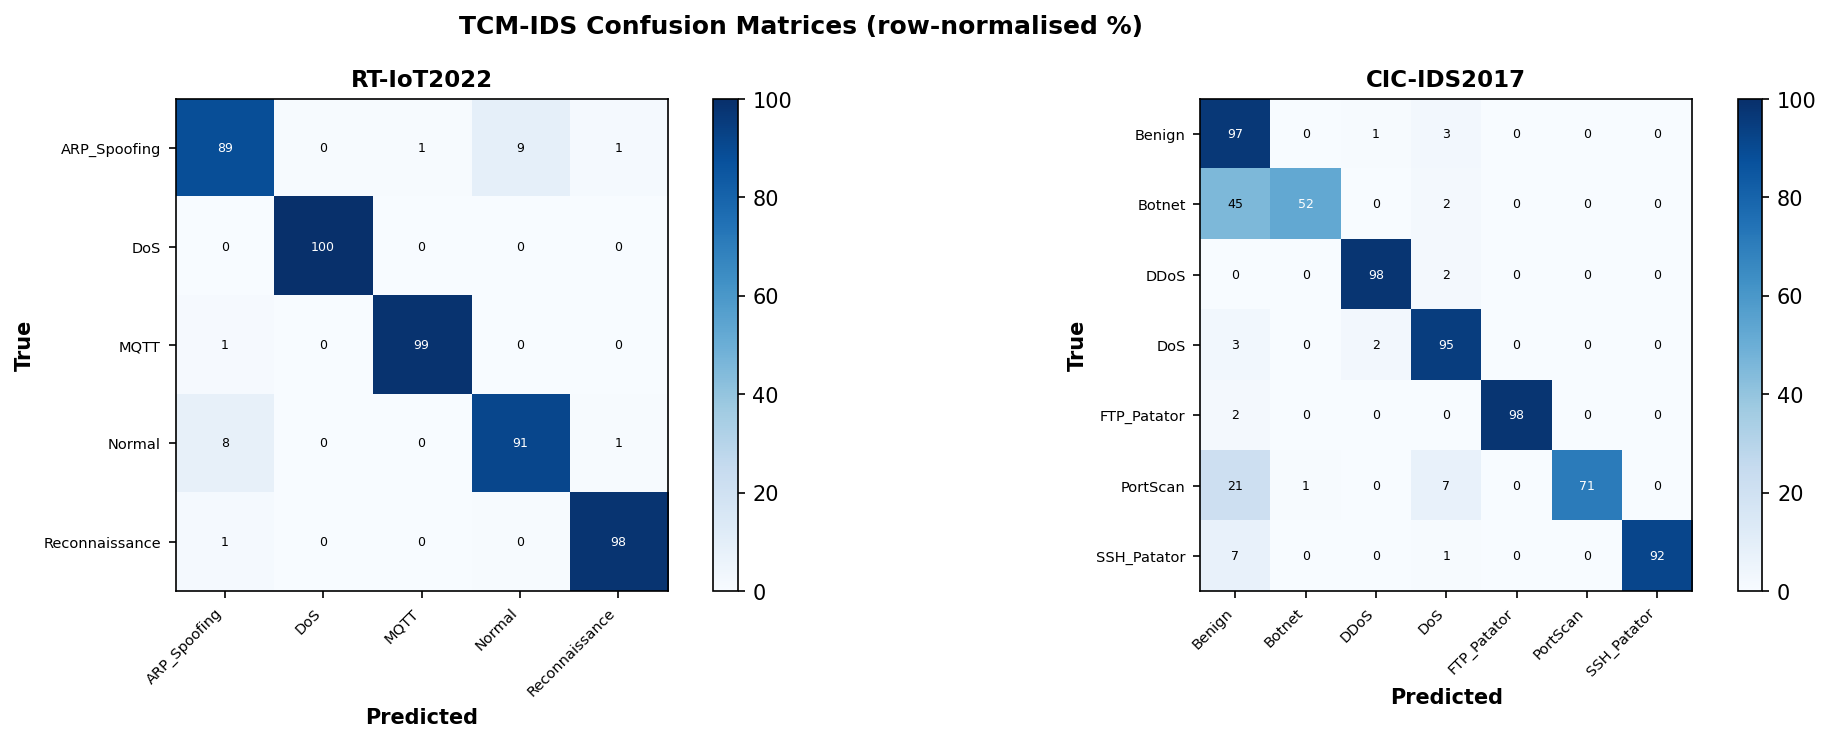

Fig 1 - Confusion Matrices (row-normalised %)
------------------------------------------------------------
  RT-IoT2022:
    ARP_Spoofing          : 88.5%  0.5%  0.6%  9.0%  1.5%
    DoS                   : 0.0%  99.8%  0.0%  0.0%  0.1%
    MQTT                  : 0.8%  0.1%  98.8%  0.0%  0.2%
    Normal                : 8.0%  0.1%  0.1%  91.3%  0.5%
    Reconnaissance        : 1.3%  0.2%  0.0%  0.4%  98.1%
  CIC-IDS2017:
    Benign                : 96.6%  0.1%  0.5%  2.7%  0.0%  0.1%  0.0%
    Botnet                : 45.5%  52.4%  0.0%  2.1%  0.0%  0.0%  0.0%
    DDoS                  : 0.2%  0.0%  97.8%  2.0%  0.0%  0.0%  0.0%
    DoS                   : 2.8%  0.0%  2.5%  94.7%  0.0%  0.0%  0.0%
    FTP_Patator           : 2.0%  0.0%  0.0%  0.0%  97.9%  0.1%  0.0%
    PortScan              : 21.5%  0.5%  0.0%  7.2%  0.0%  70.8%  0.0%
    SSH_Patator           : 7.3%  0.0%  0.0%  0.8%  0.2%  0.0%  91.8%



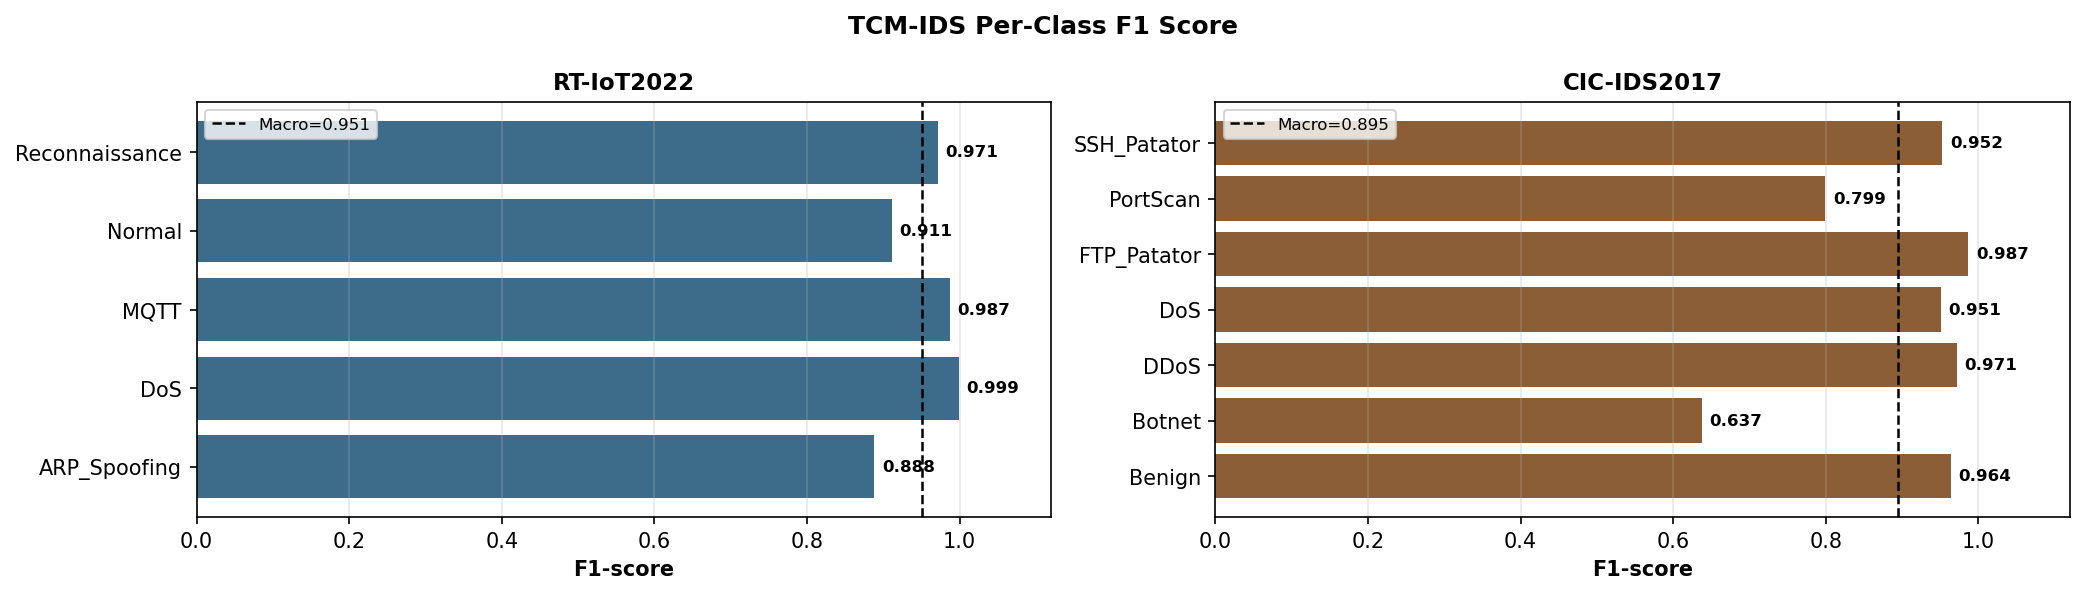

Fig 2 - Per-Class F1 Score
------------------------------------------------------------
  RT-IoT2022  (Macro-F1=0.9513):
    ARP_Spoofing          : 0.8880
    DoS                   : 0.9986
    MQTT                  : 0.9873
    Normal                : 0.9113
    Reconnaissance        : 0.9711
  CIC-IDS2017  (Macro-F1=0.8945):
    Benign                : 0.9636
    Botnet                : 0.6371
    DDoS                  : 0.9715
    DoS                   : 0.9506
    FTP_Patator           : 0.9868
    PortScan              : 0.7994
    SSH_Patator           : 0.9525



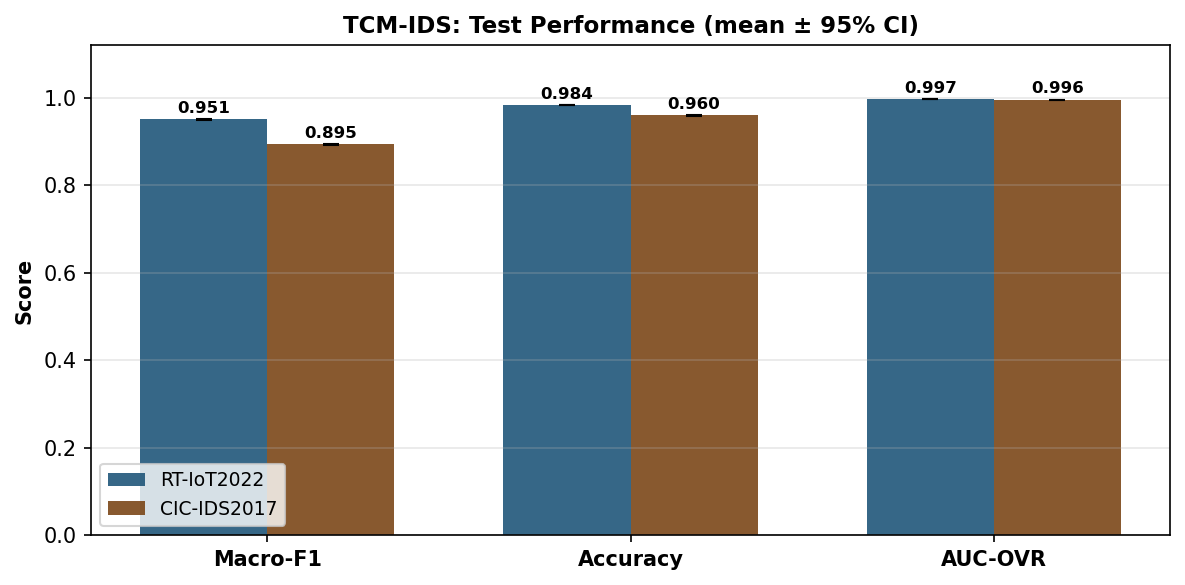

Fig 3 - Summary Metrics (mean ± 95% CI across 5 seeds)
------------------------------------------------------------
  RT-IoT2022:
    Macro-F1 : 0.9513  (CI ± 0.0005)
    Accuracy : 0.9836  (CI ± 0.0001)
    AUC-OVR  : 0.9972  (CI ± 0.0002)
    Kappa    : 0.9579
    MCC      : 0.9579
  CIC-IDS2017:
    Macro-F1 : 0.8945  (CI ± 0.0010)
    Accuracy : 0.9602  (CI ± 0.0009)
    AUC-OVR  : 0.9958  (CI ± 0.0004)
    Kappa    : 0.9417
    MCC      : 0.9417

CELL 7 COMPLETE


In [28]:
# CELL 7: Figures
print('CELL 7: Figures\n')

DS_LIST = ['rt_iot', 'cicids2017']
DS_COLOURS_NEW = {'rt_iot': '#1a5276', 'cicids2017': '#784212'} 

# Fig 1: Confusion matrices 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds_name in zip(axes, DS_LIST):
    r      = results[ds_name]
    cm     = confusion_matrix(r['y_true'], r['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im     = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ticks  = range(len(r['classes']))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(r['classes'], rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(r['classes'], fontsize=7)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True', fontweight='bold')
    ax.set_title(DS_LABELS[ds_name], fontweight='bold')
    for i in range(len(r['classes'])):
        for j in range(len(r['classes'])):
            ax.text(j, i, f'{cm_pct[i,j]:.0f}', ha='center', va='center',
                    fontsize=6, color='white' if cm_pct[i,j] > 50 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('TCM-IDS Confusion Matrices (row-normalised %)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

print('Fig 1 - Confusion Matrices (row-normalised %)')
print('------------------------------------------------------------')
for ds_name in DS_LIST:
    r = results[ds_name]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    print(f'  {DS_LABELS[ds_name]}:')
    for i, cls in enumerate(r['classes']):
        row = '  '.join([f'{cm_pct[i,j]:.1f}%' for j in range(len(r['classes']))])
        print(f'    {cls:<22}: {row}')
print()

# Fig 2: Per-class F1 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ds_name in zip(axes, DS_LIST):
    r    = results[ds_name]
    bars = ax.barh(r['classes'], r['per_class_f1'],
                   color=DS_COLOURS_NEW[ds_name], alpha=0.85)
    for bar, v in zip(bars, r['per_class_f1']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8, fontweight='bold')
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('F1-score', fontweight='bold')
    ax.set_title(DS_LABELS[ds_name], fontweight='bold')
    ax.axvline(r['macro_f1'], color='black', ls='--', lw=1.2,
               label=f'Macro={r["macro_f1"]:.3f}')
    ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
plt.suptitle('TCM-IDS Per-Class F1 Score', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'fig_perclass_f1.png', bbox_inches='tight')
plt.show()

print('Fig 2 - Per-Class F1 Score')
print('------------------------------------------------------------')
for ds_name in DS_LIST:
    r = results[ds_name]
    print(f'  {DS_LABELS[ds_name]}  (Macro-F1={r["macro_f1"]:.4f}):')
    for cls, f in zip(r['classes'], r['per_class_f1']):
        print(f'    {cls:<22}: {f:.4f}')
print()

# Fig 3: Summary bar chart (Macro-F1, Accuracy, AUC)
metrics  = ['macro_f1', 'accuracy', 'auc']
mlabels  = ['Macro-F1', 'Accuracy', 'AUC-OVR']
x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
for i, ds_name in enumerate(DS_LIST):
    r     = results[ds_name]
    ms    = ms_results[ds_name]
    means = [r['macro_f1'], r['accuracy'], r['auc']]
    cis   = [ms['f1_ci'],   ms['acc_ci'],  ms['auc_ci']]
    bars  = ax.bar(x + (i-0.5)*w, means, w, yerr=cis, capsize=4,
                   label=DS_LABELS[ds_name],
                   color=DS_COLOURS_NEW[ds_name], alpha=0.88)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{m:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(mlabels, fontweight='bold')
ax.set_ylim(0, 1.12); ax.set_ylabel('Score', fontweight='bold')
ax.set_title('TCM-IDS: Test Performance (mean ± 95% CI)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'fig_summary_metrics.png', bbox_inches='tight')
plt.show()

print('Fig 3 - Summary Metrics (mean ± 95% CI across 5 seeds)')
print('------------------------------------------------------------')
for ds_name in DS_LIST:
    r  = results[ds_name]
    ms = ms_results[ds_name]
    print(f'  {DS_LABELS[ds_name]}:')
    print(f'    Macro-F1 : {r["macro_f1"]:.4f}  (CI ± {ms["f1_ci"]:.4f})')
    print(f'    Accuracy : {r["accuracy"]:.4f}  (CI ± {ms["acc_ci"]:.4f})')
    print(f'    AUC-OVR  : {r["auc"]:.4f}  (CI ± {ms["auc_ci"]:.4f})')
    print(f'    Kappa    : {r["kappa"]:.4f}')
    print(f'    MCC      : {r["mcc"]:.4f}')
print()

print('CELL 7 COMPLETE')

CELL 8: Latency Benchmark

[RT-IoT2022] Compiling with TorchScript...
  TorchScript compiled successfully.
  Avg=3.923ms  P50=3.891ms  P99=5.985ms
  Inf-only tput : 255 pkt/s
  Batch tput    : 861 pkt/s  (28.58s / 24,601 samples)
  U=0.3923 (LL bound=0.828) → Schedulable: True

[CIC-IDS2017] Compiling with TorchScript...
  TorchScript compiled successfully.
  Avg=3.588ms  P50=3.573ms  P99=5.608ms
  Inf-only tput : 279 pkt/s
  Batch tput    : 862 pkt/s  (102.26s / 88,097 samples)
  U=0.3588 (LL bound=0.828) → Schedulable: True



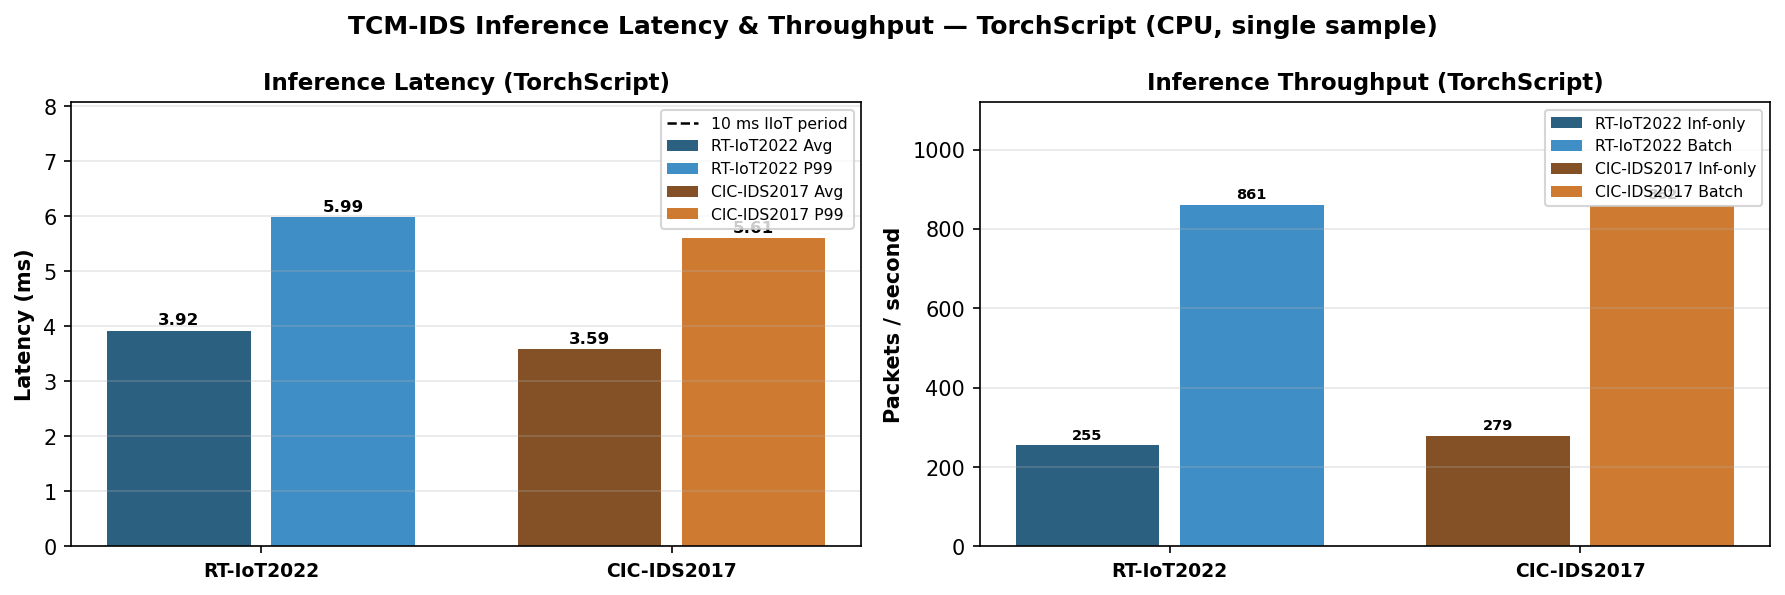

Fig 4 — Latency & Throughput (TorchScript)
------------------------------------------------------------
  RT-IoT2022:
    Avg latency   : 3.923 ms
    P50 latency   : 3.891 ms
    P99 latency   : 5.985 ms
    Inf-only tput : 255 pkt/s
    Batch tput    : 861 pkt/s
    U=0.3923 (LL bound=0.828) → Schedulable: True
  CIC-IDS2017:
    Avg latency   : 3.588 ms
    P50 latency   : 3.573 ms
    P99 latency   : 5.608 ms
    Inf-only tput : 279 pkt/s
    Batch tput    : 862 pkt/s
    U=0.3588 (LL bound=0.828) → Schedulable: True

CELL 8 COMPLETE


In [26]:
# CELL 8: Inference Latency & Throughput Benchmark
print('CELL 8: Latency Benchmark\n')

WARMUP = 50; N_RUNS = 500
bench  = {}

bench_map = {
    'rt_iot':    (models['rt_iot'],    n_feat_rt,  X_te_rt,  y_te_rt),
    'cicids2017':(models['cicids2017'],n_feat_cic, X_te,     y_te),
}

for ds_name, (clf, n_feat, X_te_b, y_te_b) in bench_map.items():
    tag = DS_LABELS[ds_name]
    clf.eval()
    print(f'[{tag}] Compiling with TorchScript...')

    # TorchScript compilation
    dummy = torch.randn(1, SEQ_LEN, n_feat)
    try:
        scripted = torch.jit.trace(clf, dummy)
        scripted = torch.jit.freeze(scripted)
        print(f'  TorchScript compiled successfully.')
    except Exception as e:
        print(f'  TorchScript failed ({e}), falling back to eager mode.')
        scripted = clf

    # Warmup 
    with torch.no_grad():
        for _ in range(WARMUP): _ = scripted(dummy)

    # Single-sample latency (500 runs)
    lats = []
    with torch.no_grad():
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            _  = scripted(dummy)
            lats.append((time.perf_counter() - t0) * 1000)

    # Batch throughput
    te_ds_b  = SlidingWindowDataset(X_te_b, y_te_b, SEQ_LEN)
    te_ldr_b = DataLoader(te_ds_b, BATCH_INFER, shuffle=False, num_workers=0)
    t0 = time.perf_counter()
    with torch.no_grad():
        for xb, _ in te_ldr_b: _ = scripted(xb)
    batch_time = time.perf_counter() - t0

    avg  = float(np.mean(lats))
    p50  = float(np.percentile(lats, 50))
    p99  = float(np.percentile(lats, 99))
    tput = 1000.0 / avg
    btput= len(te_ds_b) / batch_time

    # Liu-Layland schedulability (T=10ms IIoT period) 
    T  = 10.0   # ms - IIoT sensing period
    U  = avg / T
    UB = 2 * (2**0.5 - 1)   # ≈ 0.828

    bench[ds_name] = dict(avg_ms=avg, p50_ms=p50, p99_ms=p99,
                          inf_tput=tput, batch_tput=btput,
                          U=U, schedulable=U<=UB)

    print(f'  Avg={avg:.3f}ms  P50={p50:.3f}ms  P99={p99:.3f}ms')
    print(f'  Inf-only tput : {tput:,.0f} pkt/s')
    print(f'  Batch tput    : {btput:,.0f} pkt/s  ({batch_time:.2f}s / {len(te_ds_b):,} samples)')
    print(f'  U={U:.4f} (LL bound={UB:.3f}) → Schedulable: {U<=UB}\n')

pd.DataFrame(bench).T.to_csv(OUT / 'latency_benchmark.csv')

# Fig 4: Latency & Throughput
ds_list  = list(bench.keys())
labels_b = [DS_LABELS[d] for d in ds_list]
avgs     = [bench[d]['avg_ms'] for d in ds_list]
p50s     = [bench[d]['p50_ms'] for d in ds_list]
p99s     = [bench[d]['p99_ms'] for d in ds_list]
tputs    = [bench[d]['inf_tput']   for d in ds_list]
btputs   = [bench[d]['batch_tput'] for d in ds_list]
x_b      = np.arange(len(ds_list))

# Four distinct colours - one per bar type
CLR_RT_AVG  = '#1a5276'   # dark navy    - RT-IoT2022 Avg
CLR_RT_P99  = '#2e86c1'   # mid blue     - RT-IoT2022 P99
CLR_CIC_AVG = '#784212'   # dark brown   - CIC-IDS2017 Avg
CLR_CIC_P99 = '#ca6f1e'   # amber        - CIC-IDS2017 P99

CLR_RT_INF  = '#1a5276'
CLR_RT_BAT  = '#2e86c1'
CLR_CIC_INF = '#784212'
CLR_CIC_BAT = '#ca6f1e'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: latency
bar_rt_avg  = ax1.bar(x_b[0] - 0.2, avgs[0],  0.35,
                      color=CLR_RT_AVG,  alpha=0.92, label='RT-IoT2022 Avg')
bar_rt_p99  = ax1.bar(x_b[0] + 0.2, p99s[0],  0.35,
                      color=CLR_RT_P99,  alpha=0.92, label='RT-IoT2022 P99')
bar_cic_avg = ax1.bar(x_b[1] - 0.2, avgs[1],  0.35,
                      color=CLR_CIC_AVG, alpha=0.92, label='CIC-IDS2017 Avg')
bar_cic_p99 = ax1.bar(x_b[1] + 0.2, p99s[1],  0.35,
                      color=CLR_CIC_P99, alpha=0.92, label='CIC-IDS2017 P99')

for bar in [bar_rt_avg, bar_rt_p99, bar_cic_avg, bar_cic_p99]:
    h = bar[0].get_height()
    ax1.text(bar[0].get_x() + bar[0].get_width()/2, h + 0.05,
             f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.axhline(10.0, ls='--', c='k', lw=1.2, label='10 ms IIoT period')
ax1.set_xticks(x_b)
ax1.set_xticklabels(labels_b, fontsize=9, fontweight='bold')
ax1.set_ylabel('Latency (ms)', fontweight='bold')
ax1.set_title('Inference Latency (TorchScript)', fontweight='bold')
ax1.set_ylim(0, max(p99s) * 1.35)
ax1.legend(fontsize=7.5, frameon=True, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Right: throughput
bar_rt_inf  = ax2.bar(x_b[0] - 0.2, tputs[0],  0.35,
                      color=CLR_RT_INF,  alpha=0.92, label='RT-IoT2022 Inf-only')
bar_rt_bat  = ax2.bar(x_b[0] + 0.2, btputs[0], 0.35,
                      color=CLR_RT_BAT,  alpha=0.92, label='RT-IoT2022 Batch')
bar_cic_inf = ax2.bar(x_b[1] - 0.2, tputs[1],  0.35,
                      color=CLR_CIC_INF, alpha=0.92, label='CIC-IDS2017 Inf-only')
bar_cic_bat = ax2.bar(x_b[1] + 0.2, btputs[1], 0.35,
                      color=CLR_CIC_BAT, alpha=0.92, label='CIC-IDS2017 Batch')

for bar in [bar_rt_inf, bar_rt_bat, bar_cic_inf, bar_cic_bat]:
    h = bar[0].get_height()
    ax2.text(bar[0].get_x() + bar[0].get_width()/2, h + 8,
             f'{h:,.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax2.set_xticks(x_b)
ax2.set_xticklabels(labels_b, fontsize=9, fontweight='bold')
ax2.set_ylabel('Packets / second', fontweight='bold')
ax2.set_title('Inference Throughput (TorchScript)', fontweight='bold')
ax2.set_ylim(0, max(btputs) * 1.3)
ax2.legend(fontsize=7.5, frameon=True, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('TCM-IDS Inference Latency & Throughput - TorchScript (CPU, single sample)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'fig_latency_throughput.png', bbox_inches='tight')
plt.show()

print('Fig 4 - Latency & Throughput (TorchScript)')
print('------------------------------------------------------------')
UB = 2*(2**0.5 - 1)
for ds_name, b in bench.items():
    print(f'  {DS_LABELS[ds_name]}:')
    print(f'    Avg latency   : {b["avg_ms"]:.3f} ms')
    print(f'    P50 latency   : {b["p50_ms"]:.3f} ms')
    print(f'    P99 latency   : {b["p99_ms"]:.3f} ms')
    print(f'    Inf-only tput : {b["inf_tput"]:,.0f} pkt/s')
    print(f'    Batch tput    : {b["batch_tput"]:,.0f} pkt/s')
    print(f'    U={b["U"]:.4f} (LL bound={UB:.3f}) → Schedulable: {b["schedulable"]}')
print()
print('CELL 8 COMPLETE')